In [1]:
!pip install Sastrawi
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import nltk
from nltk.corpus import stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
import re

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 4.1 MB/s eta 0:00:00


In [ ]:
tabelbaru1 = pd.read_csv("/content/result.csv",lineterminator='\n')
tabelbaru1 = tabelbaru1[['created_at','username', 'full_text']]
tabelbaru1

,created_at,username,full_text
0,Sat Apr 27 23:49:18 +0000 2019,HairulA57926897,@ronavioleta @jokowi Kwkwkkww kwkwkwkwkw cuma ...
1,Sat Apr 27 23:37:18 +0000 2019,fandyyy1,robot diasmu hahahah cok jokowi cebong #Fisip...
2,Sat Apr 27 23:24:52 +0000 2019,txtdarireyy,@rinibagyo @fadjroeL @Aan_Hantorov @jokowi Itu...
3,Sat Apr 27 22:58:43 +0000 2019,apriliyan_rios,@ManogiSimarmata @Dennysiregar7 @jokowi @prabo...
4,Sat Apr 27 22:55:37 +0000 2019,RFauzy5,@UnoJawa @FangidaeYane @ahankiki @prabowo @san...
...,...,...,...
1619,Sun Jan 27 16:48:47 +0000 2019,IvanBoediman,Pihak Bank Sebut e-money Bergambar Prabowo-San...
1620,Sun Jan 27 16:46:51 +0000 2019,BarzanyWA,"@sudjiwotedjo Mbah jancukers kami sudah tau, k..."
1621,Sun Jan 27 16:46:28 +0000 2019,MEDIAEXPGROUP,"Ajak Pilih Prabowo-Sandi, Kader PKS DPD Bengka..."
1622,Sun Jan 27 16:44:32 +0000 2019,jerhyunct,Prabowo-Sandi Tarik Kader NU Jadi Menteri Agam...


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Case-Folding

In [ ]:
tabelbaru1 = tabelbaru1.applymap(lambda x: x.lower() if isinstance(x, str) else x)
tabelbaru1

,created_at,username,full_text
0,sat apr 27 23:49:18 +0000 2019,hairula57926897,@ronavioleta @jokowi kwkwkkww kwkwkwkwkw cuma ...
1,sat apr 27 23:37:18 +0000 2019,fandyyy1,robot diasmu hahahah cok jokowi cebong #fisip...
2,sat apr 27 23:24:52 +0000 2019,txtdarireyy,@rinibagyo @fadjroel @aan_hantorov @jokowi itu...
3,sat apr 27 22:58:43 +0000 2019,apriliyan_rios,@manogisimarmata @dennysiregar7 @jokowi @prabo...
4,sat apr 27 22:55:37 +0000 2019,rfauzy5,@unojawa @fangidaeyane @ahankiki @prabowo @san...
...,...,...,...
1619,sun jan 27 16:48:47 +0000 2019,ivanboediman,pihak bank sebut e-money bergambar prabowo-san...
1620,sun jan 27 16:46:51 +0000 2019,barzanywa,"@sudjiwotedjo mbah jancukers kami sudah tau, k..."
1621,sun jan 27 16:46:28 +0000 2019,mediaexpgroup,"ajak pilih prabowo-sandi, kader pks dpd bengka..."
1622,sun jan 27 16:44:32 +0000 2019,jerhyunct,prabowo-sandi tarik kader nu jadi menteri agam...


# Cleaning

In [ ]:
tabelbaru2 = tabelbaru1.replace(r'http\S+', '', regex=True).replace(r'www\S+', '', regex=True)
tabelbaru2.rename(columns = {'full_text':'hapus_link'}, inplace = True)
display(pd.concat([tabelbaru1, tabelbaru2['hapus_link']], axis=1))

,created_at,username,full_text,hapus_link
0,sat apr 27 23:49:18 +0000 2019,hairula57926897,@ronavioleta @jokowi kwkwkkww kwkwkwkwkw cuma ...,@ronavioleta @jokowi kwkwkkww kwkwkwkwkw cuma ...
1,sat apr 27 23:37:18 +0000 2019,fandyyy1,robot diasmu hahahah cok jokowi cebong #fisip...,robot diasmu hahahah cok jokowi cebong #fisip...
2,sat apr 27 23:24:52 +0000 2019,txtdarireyy,@rinibagyo @fadjroel @aan_hantorov @jokowi itu...,@rinibagyo @fadjroel @aan_hantorov @jokowi itu...
3,sat apr 27 22:58:43 +0000 2019,apriliyan_rios,@manogisimarmata @dennysiregar7 @jokowi @prabo...,@manogisimarmata @dennysiregar7 @jokowi @prabo...
4,sat apr 27 22:55:37 +0000 2019,rfauzy5,@unojawa @fangidaeyane @ahankiki @prabowo @san...,@unojawa @fangidaeyane @ahankiki @prabowo @san...
...,...,...,...,...
1619,sun jan 27 16:48:47 +0000 2019,ivanboediman,pihak bank sebut e-money bergambar prabowo-san...,pihak bank sebut e-money bergambar prabowo-san...
1620,sun jan 27 16:46:51 +0000 2019,barzanywa,"@sudjiwotedjo mbah jancukers kami sudah tau, k...","@sudjiwotedjo mbah jancukers kami sudah tau, k..."
1621,sun jan 27 16:46:28 +0000 2019,mediaexpgroup,"ajak pilih prabowo-sandi, kader pks dpd bengka...","ajak pilih prabowo-sandi, kader pks dpd bengka..."
1622,sun jan 27 16:44:32 +0000 2019,jerhyunct,prabowo-sandi tarik kader nu jadi menteri agam...,prabowo-sandi tarik kader nu jadi menteri agam...


In [ ]:
def remov(tweet):
  #remove hashtag
  tweet = re.sub(r'#\S+', '', tweet)

  return tweet
tabelbaru2['remove_hashtag'] = tabelbaru2['hapus_link'].apply(lambda x: remov(x))
display(pd.concat([tabelbaru1, tabelbaru2['hapus_link'], tabelbaru2['remove_hashtag']], axis=1))

,created_at,username,full_text,hapus_link,remove_hashtag
0,sat apr 27 23:49:18 +0000 2019,hairula57926897,@ronavioleta @jokowi kwkwkkww kwkwkwkwkw cuma ...,@ronavioleta @jokowi kwkwkkww kwkwkwkwkw cuma ...,@ronavioleta @jokowi kwkwkkww kwkwkwkwkw cuma ...
1,sat apr 27 23:37:18 +0000 2019,fandyyy1,robot diasmu hahahah cok jokowi cebong #fisip...,robot diasmu hahahah cok jokowi cebong #fisip...,robot diasmu hahahah cok jokowi cebong
2,sat apr 27 23:24:52 +0000 2019,txtdarireyy,@rinibagyo @fadjroel @aan_hantorov @jokowi itu...,@rinibagyo @fadjroel @aan_hantorov @jokowi itu...,@rinibagyo @fadjroel @aan_hantorov @jokowi itu...
3,sat apr 27 22:58:43 +0000 2019,apriliyan_rios,@manogisimarmata @dennysiregar7 @jokowi @prabo...,@manogisimarmata @dennysiregar7 @jokowi @prabo...,@manogisimarmata @dennysiregar7 @jokowi @prabo...
4,sat apr 27 22:55:37 +0000 2019,rfauzy5,@unojawa @fangidaeyane @ahankiki @prabowo @san...,@unojawa @fangidaeyane @ahankiki @prabowo @san...,@unojawa @fangidaeyane @ahankiki @prabowo @san...
...,...,...,...,...,...
1619,sun jan 27 16:48:47 +0000 2019,ivanboediman,pihak bank sebut e-money bergambar prabowo-san...,pihak bank sebut e-money bergambar prabowo-san...,pihak bank sebut e-money bergambar prabowo-san...
1620,sun jan 27 16:46:51 +0000 2019,barzanywa,"@sudjiwotedjo mbah jancukers kami sudah tau, k...","@sudjiwotedjo mbah jancukers kami sudah tau, k...","@sudjiwotedjo mbah jancukers kami sudah tau, k..."
1621,sun jan 27 16:46:28 +0000 2019,mediaexpgroup,"ajak pilih prabowo-sandi, kader pks dpd bengka...","ajak pilih prabowo-sandi, kader pks dpd bengka...","ajak pilih prabowo-sandi, kader pks dpd bengka..."
1622,sun jan 27 16:44:32 +0000 2019,jerhyunct,prabowo-sandi tarik kader nu jadi menteri agam...,prabowo-sandi tarik kader nu jadi menteri agam...,prabowo-sandi tarik kader nu jadi menteri agam...


In [ ]:
# Fungsi untuk menghilangkan stop words dari teks
def remove(text):
    words = text.split()
    filtered_words = [word for word in words]
    # Menghapus tanda "@" dan kata setelah "@" kecuali "Jokowi" dan "Prabowo"
    filtered_words = [re.sub(r'@[^ ]+', '', word) if not re.match(r'@(?:Jokowi|Prabowo|jokowi|prabowo)', word) else word for word in filtered_words]
    return ' '.join(filtered_words)
def remov(tweet):
  #remove hashtag
  tweet = re.sub(r'@', '', tweet)
  return tweet

tabelbaru2['hapus_@'] = tabelbaru2['remove_hashtag'].apply(remove)
tabelbaru2['hapus_@'] = tabelbaru2['hapus_@'].apply(lambda x: remov(x))

# Menampilkan DataFrame yang sudah diubah

display(pd.concat([tabelbaru1, tabelbaru2['hapus_link'], tabelbaru2['remove_hashtag'], tabelbaru2['hapus_@']], axis=1))

,created_at,username,full_text,hapus_link,remove_hashtag,hapus_@
0,sat apr 27 23:49:18 +0000 2019,hairula57926897,@ronavioleta @jokowi kwkwkkww kwkwkwkwkw cuma ...,@ronavioleta @jokowi kwkwkkww kwkwkwkwkw cuma ...,@ronavioleta @jokowi kwkwkkww kwkwkwkwkw cuma ...,jokowi kwkwkkww kwkwkwkwkw cuma cebong yg gob...
1,sat apr 27 23:37:18 +0000 2019,fandyyy1,robot diasmu hahahah cok jokowi cebong #fisip...,robot diasmu hahahah cok jokowi cebong #fisip...,robot diasmu hahahah cok jokowi cebong,robot diasmu hahahah cok jokowi cebong
2,sat apr 27 23:24:52 +0000 2019,txtdarireyy,@rinibagyo @fadjroel @aan_hantorov @jokowi itu...,@rinibagyo @fadjroel @aan_hantorov @jokowi itu...,@rinibagyo @fadjroel @aan_hantorov @jokowi itu...,jokowi itu yang vote bukan orang indo doang...
3,sat apr 27 22:58:43 +0000 2019,apriliyan_rios,@manogisimarmata @dennysiregar7 @jokowi @prabo...,@manogisimarmata @dennysiregar7 @jokowi @prabo...,@manogisimarmata @dennysiregar7 @jokowi @prabo...,jokowi prabowo gajelas substansi ngomong nya...
4,sat apr 27 22:55:37 +0000 2019,rfauzy5,@unojawa @fangidaeyane @ahankiki @prabowo @san...,@unojawa @fangidaeyane @ahankiki @prabowo @san...,@unojawa @fangidaeyane @ahankiki @prabowo @san...,prabowo kalau cebong disebut du...
...,...,...,...,...,...,...
1619,sun jan 27 16:48:47 +0000 2019,ivanboediman,pihak bank sebut e-money bergambar prabowo-san...,pihak bank sebut e-money bergambar prabowo-san...,pihak bank sebut e-money bergambar prabowo-san...,pihak bank sebut e-money bergambar prabowo-san...
1620,sun jan 27 16:46:51 +0000 2019,barzanywa,"@sudjiwotedjo mbah jancukers kami sudah tau, k...","@sudjiwotedjo mbah jancukers kami sudah tau, k...","@sudjiwotedjo mbah jancukers kami sudah tau, k...","mbah jancukers kami sudah tau, kalau mbah dal..."
1621,sun jan 27 16:46:28 +0000 2019,mediaexpgroup,"ajak pilih prabowo-sandi, kader pks dpd bengka...","ajak pilih prabowo-sandi, kader pks dpd bengka...","ajak pilih prabowo-sandi, kader pks dpd bengka...","ajak pilih prabowo-sandi, kader pks dpd bengka..."
1622,sun jan 27 16:44:32 +0000 2019,jerhyunct,prabowo-sandi tarik kader nu jadi menteri agam...,prabowo-sandi tarik kader nu jadi menteri agam...,prabowo-sandi tarik kader nu jadi menteri agam...,prabowo-sandi tarik kader nu jadi menteri agam...


In [ ]:
#remove emoji
def remove_emojis(data):
    emoj = re.compile("["
        u"\U0001F600-\U0001F64F"  # emoticons
        u"\U0001F300-\U0001F5FF"  # symbols & pictographs
        u"\U0001F680-\U0001F6FF"  # transport & map symbols
        u"\U0001F1E0-\U0001F1FF"  # flags (iOS)
        u"\U00002500-\U00002BEF"  # chinese char
        u"\U00002702-\U000027B0"
        u"\U000024C2-\U0001F251"
        u"\U0001f926-\U0001f937"
        u"\U00010000-\U0010ffff"
        u"\u2640-\u2642"
        u"\u2600-\u2B55"
        u"\u200d"
        u"\u23cf"
        u"\u23e9"
        u"\u231a"
        u"\ufe0f"  # dingbats
        u"\u3030"
                      "]+", re.UNICODE)
    return re.sub(emoj, '', data)

tabelbaru2['clean'] = tabelbaru2['hapus_@'].apply(lambda x: remove_emojis(x))
display(pd.concat([tabelbaru1['full_text'], tabelbaru2['clean']], axis=1))

,full_text,clean
0,@ronavioleta @jokowi kwkwkkww kwkwkwkwkw cuma ...,jokowi kwkwkkww kwkwkwkwkw cuma cebong yg gob...
1,robot diasmu hahahah cok jokowi cebong #fisip...,robot diasmu hahahah cok jokowi cebong
2,@rinibagyo @fadjroel @aan_hantorov @jokowi itu...,jokowi itu yang vote bukan orang indo doang...
3,@manogisimarmata @dennysiregar7 @jokowi @prabo...,jokowi prabowo gajelas substansi ngomong nya...
4,@unojawa @fangidaeyane @ahankiki @prabowo @san...,prabowo kalau cebong disebut du...
...,...,...
1619,pihak bank sebut e-money bergambar prabowo-san...,pihak bank sebut e-money bergambar prabowo-san...
1620,"@sudjiwotedjo mbah jancukers kami sudah tau, k...","mbah jancukers kami sudah tau, kalau mbah dal..."
1621,"ajak pilih prabowo-sandi, kader pks dpd bengka...","ajak pilih prabowo-sandi, kader pks dpd bengka..."
1622,prabowo-sandi tarik kader nu jadi menteri agam...,prabowo-sandi tarik kader nu jadi menteri agam...


In [ ]:
#hapus angka
tabelbaru2['clean_final'] = tabelbaru2['clean'].replace('\d+', '', regex=True)
display(pd.concat([tabelbaru1['full_text'], tabelbaru2['clean'], tabelbaru2['clean_final']], axis=1))

,full_text,clean,clean_final
0,@ronavioleta @jokowi kwkwkkww kwkwkwkwkw cuma ...,jokowi kwkwkkww kwkwkwkwkw cuma cebong yg gob...,jokowi kwkwkkww kwkwkwkwkw cuma cebong yg gob...
1,robot diasmu hahahah cok jokowi cebong #fisip...,robot diasmu hahahah cok jokowi cebong,robot diasmu hahahah cok jokowi cebong
2,@rinibagyo @fadjroel @aan_hantorov @jokowi itu...,jokowi itu yang vote bukan orang indo doang...,jokowi itu yang vote bukan orang indo doang...
3,@manogisimarmata @dennysiregar7 @jokowi @prabo...,jokowi prabowo gajelas substansi ngomong nya...,jokowi prabowo gajelas substansi ngomong nya...
4,@unojawa @fangidaeyane @ahankiki @prabowo @san...,prabowo kalau cebong disebut du...,prabowo kalau cebong disebut du...
...,...,...,...
1619,pihak bank sebut e-money bergambar prabowo-san...,pihak bank sebut e-money bergambar prabowo-san...,pihak bank sebut e-money bergambar prabowo-san...
1620,"@sudjiwotedjo mbah jancukers kami sudah tau, k...","mbah jancukers kami sudah tau, kalau mbah dal...","mbah jancukers kami sudah tau, kalau mbah dal..."
1621,"ajak pilih prabowo-sandi, kader pks dpd bengka...","ajak pilih prabowo-sandi, kader pks dpd bengka...","ajak pilih prabowo-sandi, kader pks dpd bengka..."
1622,prabowo-sandi tarik kader nu jadi menteri agam...,prabowo-sandi tarik kader nu jadi menteri agam...,prabowo-sandi tarik kader nu jadi menteri agam...


# Stopword

In [ ]:
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')
print(stopwords.words('indonesian'))
stop_word = stopwords.words('indonesian')

['ada', 'adalah', 'adanya', 'adapun', 'agak', 'agaknya', 'agar', 'akan', 'akankah', 'akhir', 'akhiri', 'akhirnya', 'aku', 'akulah', 'amat', 'amatlah', 'anda', 'andalah', 'antar', 'antara', 'antaranya', 'apa', 'apaan', 'apabila', 'apakah', 'apalagi', 'apatah', 'artinya', 'asal', 'asalkan', 'atas', 'atau', 'ataukah', 'ataupun', 'awal', 'awalnya', 'bagai', 'bagaikan', 'bagaimana', 'bagaimanakah', 'bagaimanapun', 'bagi', 'bagian', 'bahkan', 'bahwa', 'bahwasanya', 'baik', 'bakal', 'bakalan', 'balik', 'banyak', 'bapak', 'baru', 'bawah', 'beberapa', 'begini', 'beginian', 'beginikah', 'beginilah', 'begitu', 'begitukah', 'begitulah', 'begitupun', 'bekerja', 'belakang', 'belakangan', 'belum', 'belumlah', 'benar', 'benarkah', 'benarlah', 'berada', 'berakhir', 'berakhirlah', 'berakhirnya', 'berapa', 'berapakah', 'berapalah', 'berapapun', 'berarti', 'berawal', 'berbagai', 'berdatangan', 'beri', 'berikan', 'berikut', 'berikutnya', 'berjumlah', 'berkali-kali', 'berkata', 'berkehendak', 'berkeinginan'

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
tambahan = pd.read_csv("/content/kamus_alay.csv")
tambahan = tambahan['slang'].tolist()
print(tambahan)

['woww', 'aminn', 'met', 'netaas', 'keberpa', 'eeeehhhh', 'kata2nyaaa', 'hallo', 'kaka', 'ka', 'daah', 'aaaaahhhh', 'yaa', 'smga', 'slalu', 'amiin', 'kk', 'trus', 'kk', 'sii', 'nyenengin', 'bgt', 'gemess', 'akuuu', 'jgn', 'yaa', 'udah', 'gitu', 'aja', 'gemesiin', 'menyenangkn', 'rb', 'akau', 'saranin', 'nemuin', 'yah', 'met', 'mnis2nya', 'gtu', 'tu', 'idolaa', 'bangett', 'kaakk', 'baaiikkk', 'telaatt', 'kaak', 'yg', 'lg', 'skarang', 'yg', 'sempet', 'karna', 'ngga', 'karna', 'mantep', 'loohhh', 'yeee', 'baguuuuus', 'sampe', 'ngikutin', 'gayany', 'ngikutin', 'lg', 'bnk', 'awaas', 'siip', 'abizzzz', 'kerrrrennnn', 'sayaa', 'pengen', 'kpan', 'bgt', 'sma', 'sdkit', 'bngt', 'lgu', 'bener2', 'kharismanya', 'aq', 'yg', 'jdi', 'lgi', 'gk', 'kek', 'lgunya', 'kpan', 'kereeeeennnn', 'nyamain', 'slalu', 'lakik', 'siippp', 'bkn', 'nyangka', 'bangettt', 'kereeen', 'wihhhhhh', 'tp', 'inget', 'bingitsss', 'dmn', 'bird', 'kaloo', 'gimna', 'tuuh', 'nyebur', 'yng', 'dbuat', 'kn', 'org', 'pingin', 'bgt', '

In [ ]:
data = stop_word + tambahan
print(data)

['ada', 'adalah', 'adanya', 'adapun', 'agak', 'agaknya', 'agar', 'akan', 'akankah', 'akhir', 'akhiri', 'akhirnya', 'aku', 'akulah', 'amat', 'amatlah', 'anda', 'andalah', 'antar', 'antara', 'antaranya', 'apa', 'apaan', 'apabila', 'apakah', 'apalagi', 'apatah', 'artinya', 'asal', 'asalkan', 'atas', 'atau', 'ataukah', 'ataupun', 'awal', 'awalnya', 'bagai', 'bagaikan', 'bagaimana', 'bagaimanakah', 'bagaimanapun', 'bagi', 'bagian', 'bahkan', 'bahwa', 'bahwasanya', 'baik', 'bakal', 'bakalan', 'balik', 'banyak', 'bapak', 'baru', 'bawah', 'beberapa', 'begini', 'beginian', 'beginikah', 'beginilah', 'begitu', 'begitukah', 'begitulah', 'begitupun', 'bekerja', 'belakang', 'belakangan', 'belum', 'belumlah', 'benar', 'benarkah', 'benarlah', 'berada', 'berakhir', 'berakhirlah', 'berakhirnya', 'berapa', 'berapakah', 'berapalah', 'berapapun', 'berarti', 'berawal', 'berbagai', 'berdatangan', 'beri', 'berikan', 'berikut', 'berikutnya', 'berjumlah', 'berkali-kali', 'berkata', 'berkehendak', 'berkeinginan'

In [ ]:
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory, StopWordRemover, ArrayDictionary
dictionary = ArrayDictionary(data)
str = StopWordRemover(dictionary)
print(data)

['ada', 'adalah', 'adanya', 'adapun', 'agak', 'agaknya', 'agar', 'akan', 'akankah', 'akhir', 'akhiri', 'akhirnya', 'aku', 'akulah', 'amat', 'amatlah', 'anda', 'andalah', 'antar', 'antara', 'antaranya', 'apa', 'apaan', 'apabila', 'apakah', 'apalagi', 'apatah', 'artinya', 'asal', 'asalkan', 'atas', 'atau', 'ataukah', 'ataupun', 'awal', 'awalnya', 'bagai', 'bagaikan', 'bagaimana', 'bagaimanakah', 'bagaimanapun', 'bagi', 'bagian', 'bahkan', 'bahwa', 'bahwasanya', 'baik', 'bakal', 'bakalan', 'balik', 'banyak', 'bapak', 'baru', 'bawah', 'beberapa', 'begini', 'beginian', 'beginikah', 'beginilah', 'begitu', 'begitukah', 'begitulah', 'begitupun', 'bekerja', 'belakang', 'belakangan', 'belum', 'belumlah', 'benar', 'benarkah', 'benarlah', 'berada', 'berakhir', 'berakhirlah', 'berakhirnya', 'berapa', 'berapakah', 'berapalah', 'berapapun', 'berarti', 'berawal', 'berbagai', 'berdatangan', 'beri', 'berikan', 'berikut', 'berikutnya', 'berjumlah', 'berkali-kali', 'berkata', 'berkehendak', 'berkeinginan'

In [ ]:
!pip install Sastrawi

In [ ]:
import string
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
factory = StemmerFactory()
stemmer = factory.create_stemmer()
from nltk.tokenize import TweetTokenizer

def clean_tweets(tweet):
  tokenizer = TweetTokenizer(preserve_case = False, strip_handles = True, reduce_len = True)
  tweet_tokens = tokenizer.tokenize(tweet)
  tweets_clean = []
  for word in tweet_tokens:
    if (word not in data and
        word not in string.punctuation):
      stem_word = stemmer.stem(word)
      tweets_clean.append(stem_word)
  return ' '.join(tweets_clean)

tabelbaru2['clean_final2'] = tabelbaru2['clean_final'].apply(lambda x: clean_tweets(x))

In [ ]:
display(pd.concat([tabelbaru1['full_text'], tabelbaru2['clean'], tabelbaru2['clean_final2']], axis=1))

# Translate

In [ ]:
!pip3 install googletrans==3.1.0a0

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.1/55.1 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 22.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.4/133.4 kB 19.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 5.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.6/42.6 kB 6.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.6/53.6 kB 8.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.0/65.0 kB 9.8 MB/s eta 0:00:00
  Created wheel for googletrans: filename=googletrans-3.1.0a0-py3-none-any.whl size=16351 sha256=e42cc6202d885d4ef8506d58c225b9d20ade0e2c1ffbafdfae149029721d2add
  Stored in directory: /root/.cache/pip/wheels/50/5d/3c/8477d0af4ca2b8b1308812c09f1930863caeebc762fe265a95
Successfully built googletrans
  Attempting uninstall: chardet
    Found existing installation: chardet 5.2.0
    Uninstalling c

In [ ]:
data = [tabelbaru2['clean_final2']]
tabelbaru3 = pd.DataFrame(data)
tabelbaru3 = tabelbaru3.transpose()
tabelbaru3.to_csv('result_clean.csv', encoding='utf8', index=False)
tabelbaru3

,clean_final2
0,jokowi kwkwkkww kwkwkwkwkw cebong goblok kena ...
1,robot dias hahahah cok jokowi cebong
2,jokowi vote orang doang orang orang tuh nama ...
3,jokowi prabowo substansi nya kayak pikir oke t...
4,prabowo cebong dungu dibohongin data kayak rea...
...,...
1619,bank e-money gambar prabowo-sandi ilegal
1620,mbah jancukers tau mbah hati dukung prabowo-sandi
1621,ajak pilih prabowo-sandi kader pks dpd bengkal...
1622,prabowo-sandi tarik kader nu menteri agama pilih


In [ ]:
df = pd.read_csv('/content/result_clean.csv',lineterminator='\n')
df

,clean_final2
0,jokowi kwkwkkww kwkwkwkwkw cebong goblok kena ...
1,robot dias hahahah cok jokowi cebong
2,jokowi vote orang doang orang orang tuh nama ...
3,jokowi prabowo substansi nya kayak pikir oke t...
4,prabowo cebong dungu dibohongin data kayak rea...
...,...
1619,bank e-money gambar prabowo-sandi ilegal
1620,mbah jancukers tau mbah hati dukung prabowo-sandi
1621,ajak pilih prabowo-sandi kader pks dpd bengkal...
1622,prabowo-sandi tarik kader nu menteri agama pilih


In [ ]:
import googletrans
from googletrans import Translator
translator = Translator()
translations = {}
for column in df.columns:
  unique_elements = df[column].unique()
  for element in unique_elements:
    translations[element] = translator.translate(element, src='id', dest='en').text
translations

{'jokowi kwkwkkww kwkwkwkwkw cebong goblok kena citra murah': 'jokowi kwkwkkww kwkwkwkwkw stupid cebong gets a cheap image',
 'robot dias hahahah cok jokowi cebong': 'Dias robot hahahah, Jokowi is a cebong',
 'jokowi vote orang doang orang  orang tuh nama cebong kampret  tau jokowi kerja nya bagus': "People only vote for Jokowi, those people are the names of the bastards who know Jokowi's work is good",
 'jokowi prabowo substansi nya kayak pikir oke the point bukti esemka junjung kaum cebong produksi ngeles deh rg input nya outputnya stabil kolam': "Jokowi Prabowo's substance is like he thinks okay the point is the proof that Esemka upholds the cebongs, production is slow, rg input, output is stable, pool",
 'prabowo cebong dungu dibohongin data kayak real count cerdas teliti putus rezim jokowi hebat saking hebat nya salah hitung': "Prabowo, stupid tadpole, was lied to by data like real count, intelligent, thorough, broke up Jokowi's regime, so great it was so great, he miscalculated",

In [ ]:
df.replace(translations, inplace = True)

In [ ]:
df = df.applymap(lambda x: x.lower())
df = df.apply(lambda x: x.replace('cebong|kampret|kampreett', 'bastard', regex=True))
df = df.apply(lambda x: x.replace('tadpole', 'bastard', regex=True))
df

,clean_final2
0,jokowi kwkwkkww kwkwkwkwkw stupid bastard gets...
1,"dias robot hahahah, jokowi is a bastard"
2,"people only vote for jokowi, those people are ..."
3,jokowi prabowo's substance is like he thinks o...
4,"prabowo, stupid bastard, was lied to by data l..."
...,...
1619,prabowo's e-money bank - illegal password
1620,mbah jancukers knows that mbah will support pr...
1621,invite prabowo-sandi to vote for pks cadres in...
1622,prabowo-sandi withdraws cadres of selected min...


In [ ]:
df

,clean_final2
0,jokowi kwkwkkww kwkwkwkwkw stupid bastard gets...
1,"dias robot hahahah, jokowi is a bastard"
2,"people only vote for jokowi, those people are ..."
3,jokowi prabowo's substance is like he thinks o...
4,"prabowo, stupid bastard, was lied to by data l..."
...,...
1619,prabowo's e-money bank - illegal password
1620,mbah jancukers knows that mbah will support pr...
1621,invite prabowo-sandi to vote for pks cadres in...
1622,prabowo-sandi withdraws cadres of selected min...


In [ ]:
!pip install VaderSentiment

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 2.8 MB/s eta 0:00:00


In [ ]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
analyzer = SentimentIntensityAnalyzer()

In [ ]:
scores = [analyzer.polarity_scores(x) for x in df['clean_final2']]
print(scores)
df['Compound_Score']= [x['compound'] for x in scores]

[{'neg': 0.496, 'neu': 0.504, 'pos': 0.0, 'compound': -0.7845}, {'neg': 0.368, 'neu': 0.632, 'pos': 0.0, 'compound': -0.5423}, {'neg': 0.167, 'neu': 0.711, 'pos': 0.121, 'compound': -0.2732}, {'neg': 0.119, 'neu': 0.685, 'pos': 0.196, 'compound': 0.1531}, {'neg': 0.272, 'neu': 0.375, 'pos': 0.353, 'compound': 0.6891}, {'neg': 0.271, 'neu': 0.543, 'pos': 0.186, 'compound': -0.2732}, {'neg': 0.429, 'neu': 0.439, 'pos': 0.132, 'compound': -0.7269}, {'neg': 0.379, 'neu': 0.479, 'pos': 0.142, 'compound': -0.886}, {'neg': 0.492, 'neu': 0.317, 'pos': 0.19, 'compound': -0.6908}, {'neg': 0.467, 'neu': 0.533, 'pos': 0.0, 'compound': -0.5423}, {'neg': 0.241, 'neu': 0.759, 'pos': 0.0, 'compound': -0.5423}, {'neg': 0.326, 'neu': 0.674, 'pos': 0.0, 'compound': -0.7003}, {'neg': 0.27, 'neu': 0.492, 'pos': 0.238, 'compound': -0.1027}, {'neg': 0.368, 'neu': 0.632, 'pos': 0.0, 'compound': -0.5423}, {'neg': 0.706, 'neu': 0.294, 'pos': 0.0, 'compound': -0.802}, {'neg': 0.404, 'neu': 0.399, 'pos': 0.197, '

In [ ]:
df

,clean_final2,Compound_Score
0,jokowi kwkwkkww kwkwkwkwkw stupid bastard gets...,-0.7845
1,"dias robot hahahah, jokowi is a bastard",-0.5423
2,"people only vote for jokowi, those people are ...",-0.2732
3,jokowi prabowo's substance is like he thinks o...,0.1531
4,"prabowo, stupid bastard, was lied to by data l...",0.6891
...,...,...
1619,prabowo's e-money bank - illegal password,-0.5574
1620,mbah jancukers knows that mbah will support pr...,0.4019
1621,invite prabowo-sandi to vote for pks cadres in...,0.1531
1622,prabowo-sandi withdraws cadres of selected min...,0.0000


In [ ]:
df.loc[df['Compound_Score'] < 0, 'Sentiments'] = 'Negatif'
df.loc[df['Compound_Score'] == 0, 'Sentiments'] = 'Neutral'
df.loc[df['Compound_Score'] > 0, 'Sentiments'] = 'Positif'
df

,clean_final2,Compound_Score,Sentiments
0,jokowi kwkwkkww kwkwkwkwkw stupid bastard gets...,-0.7845,Negatif
1,"dias robot hahahah, jokowi is a bastard",-0.5423,Negatif
2,"people only vote for jokowi, those people are ...",-0.2732,Negatif
3,jokowi prabowo's substance is like he thinks o...,0.1531,Positif
4,"prabowo, stupid bastard, was lied to by data l...",0.6891,Positif
...,...,...,...
1619,prabowo's e-money bank - illegal password,-0.5574,Negatif
1620,mbah jancukers knows that mbah will support pr...,0.4019,Positif
1621,invite prabowo-sandi to vote for pks cadres in...,0.1531,Positif
1622,prabowo-sandi withdraws cadres of selected min...,0.0000,Neutral


Positif    726
Negatif    535
Neutral    363
Name: Sentiments, dtype: int64
1624


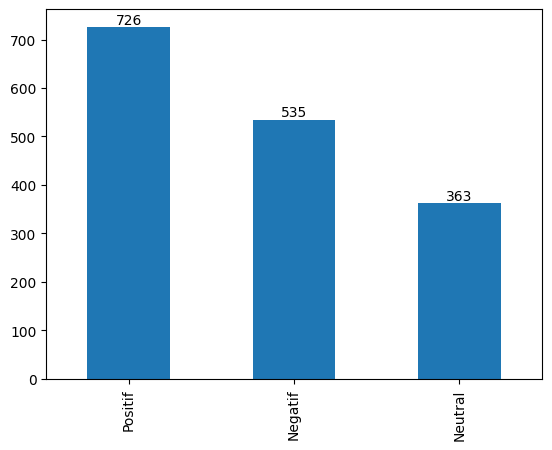

In [ ]:
s = pd.value_counts(df['Sentiments'])
print(s)
ax = s.plot.bar()
n = len(df.index)
print(n)
for container in ax.containers:
    ax.bar_label(container)

In [ ]:
df.rename(columns = {'clean_final2':'translate'}, inplace = True)
result = pd.concat([tabelbaru1['full_text'], tabelbaru2['clean_final2'], df], axis=1)
result.to_csv('hasil_akhhir.csv', encoding='utf8', index=False)

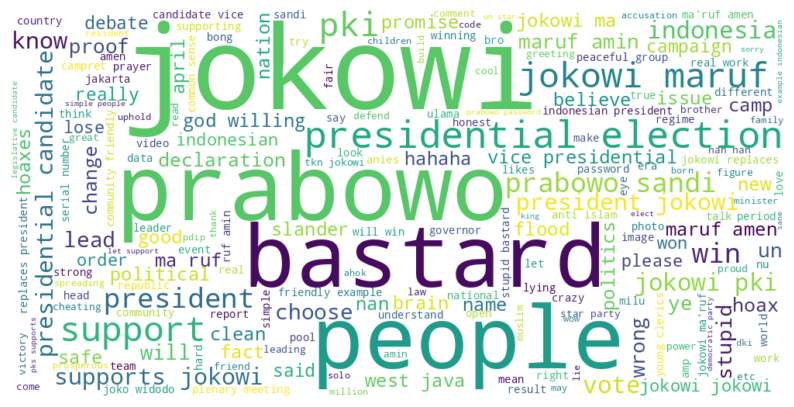

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import pandas as pd

# Ganti 'df' dengan nama DataFrame yang sesuai
df.rename(columns={'clean_final2': 'translate'}, inplace=True)

# Menggabungkan semua teks dalam kolom 'translate' menjadi satu teks panjang
all_text_translate = ' '.join(df['translate'])

# Membuat objek WordCloud dengan latar belakang putih
wordcloud_translate = WordCloud(width=1000, height=500, max_font_size=150, random_state=42, background_color='white').generate(all_text_translate)

# Membuat plot WordCloud
plt.figure(figsize=(10, 6))
plt.imshow(wordcloud_translate, interpolation="bilinear")
plt.axis("off")  # Untuk menghilangkan sumbu x dan y
plt.show()

# Menggabungkan DataFrames
result = pd.concat([tabelbaru1['full_text'], tabelbaru2['clean_final2'], df], axis=1)

# Menyimpan DataFrame ke dalam file CSV
result.to_csv('hasil_akhir.csv', encoding='utf8', index=False)


In [ ]:
df = pd.read_csv("/content/hasil_akhhir+evaluasi.csv",lineterminator='\n')
df = df.drop(['Hasil Evaluasi', '\r'], axis=1)
df = df.dropna()
df = df.drop_duplicates()